

In [38]:
import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype']=42
matplotlib.rcParams['ps.fonttype']=42
import matplotlib.pyplot as plt
import seaborn as sns

categories=['Control','Create','Edit','Delete','Query','Cross-App','Interactive']
series={
    'Communication':[0.576,0.364,0.143,0.700,0.370,0.250,0.000],
    'Calendar':[0.6364,0.1364,0.4929,0.6000,0.2963,0.1667,0.0000],
    'Query':[0.6818,0.9090,0.0000,0.6500,0.3077,0.0833,0.0000],
    'Sport':[0.5455,0.1818,0.0000,0.3000,0.4615,0.0000,0.1667]
}
fontsize=42
plt.rcParams['figure.dpi']=300
plt.rcParams['font.family']='sans-serif'
sns.set_theme(style="white",rc={"font.size":fontsize,"axes.labelsize":fontsize,"axes.titlesize":fontsize,"font.weight":"normal"})
palette=sns.color_palette("gist_earth",len(categories))
N=len(categories)
angles=np.linspace(0,2*np.pi,N,endpoint=False)
width=2*np.pi/N*0.88

fig,axs=plt.subplots(1,4,figsize=(36,11),subplot_kw=dict(projection='polar'))
names=['Communication','Calendar','Query','Sport']
tags=['(a)','(b)','(c)','(d)']

for ax,name,tag in zip(axs,names,tags):
    values=np.array(series[name])*100
    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    for i in range(N):
        ax.bar(angles[i],100,width=width,bottom=0,color=palette[i],alpha=0.12,edgecolor='white',linewidth=1.5,align='center',zorder=1)
    ax.bar(angles,values,width=width,bottom=0,color=palette,alpha=0.88,edgecolor='white',linewidth=2,align='center',zorder=3)
    ax.set_ylim(0,112)
    ax.set_yticks([20,40,60,80,100])
    ax.set_yticklabels([])
    ax.set_rlabel_position(90)
    ax.yaxis.grid(True,linestyle='--',linewidth=1.0,alpha=0.45,zorder=0)
    ax.xaxis.grid(True,linestyle='-',linewidth=0.8,alpha=0.20,zorder=0)
    ax.set_xticks(angles)
    ax.set_xticklabels([])
    for angle,label in zip(angles,categories):
        ax.text(angle,110,label,fontsize=fontsize*0.8,horizontalalignment='center',verticalalignment='center')
    for angle,value in zip(angles,values):
        r=max(min(value+12,80),20)
        ax.text(angle,r,f'{value:.0f}',fontsize=fontsize,horizontalalignment='center',verticalalignment='center',color='black',zorder=5)
    center_circle=plt.Circle((0,0),0.055,transform=ax.transAxes,color='white',ec='0.7',linewidth=1.2,zorder=10)
    ax.add_artist(center_circle)
    ax.spines['polar'].set_visible(False)
    ax.text(0.5,-0.05,f'{tag} {name}',transform=ax.transAxes,fontsize=fontsize,ha='center',va='center',fontweight='normal')

fig.suptitle('Capability Distribution of Models',fontsize=42,fontweight='normal')
plt.subplots_adjust(left=0.03,right=0.97,top=1.1,bottom=0.06,wspace=0.28)
plt.savefig('/home/zmz/Workspace/gui/figures/outputs/capability_distribution_of_models_1x4.pdf',format='pdf',bbox_inches='tight',pad_inches=0.1)
plt.savefig('/home/zmz/Workspace/gui/figures/outputs/capability_distribution_of_models_1x4.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
plt.show()

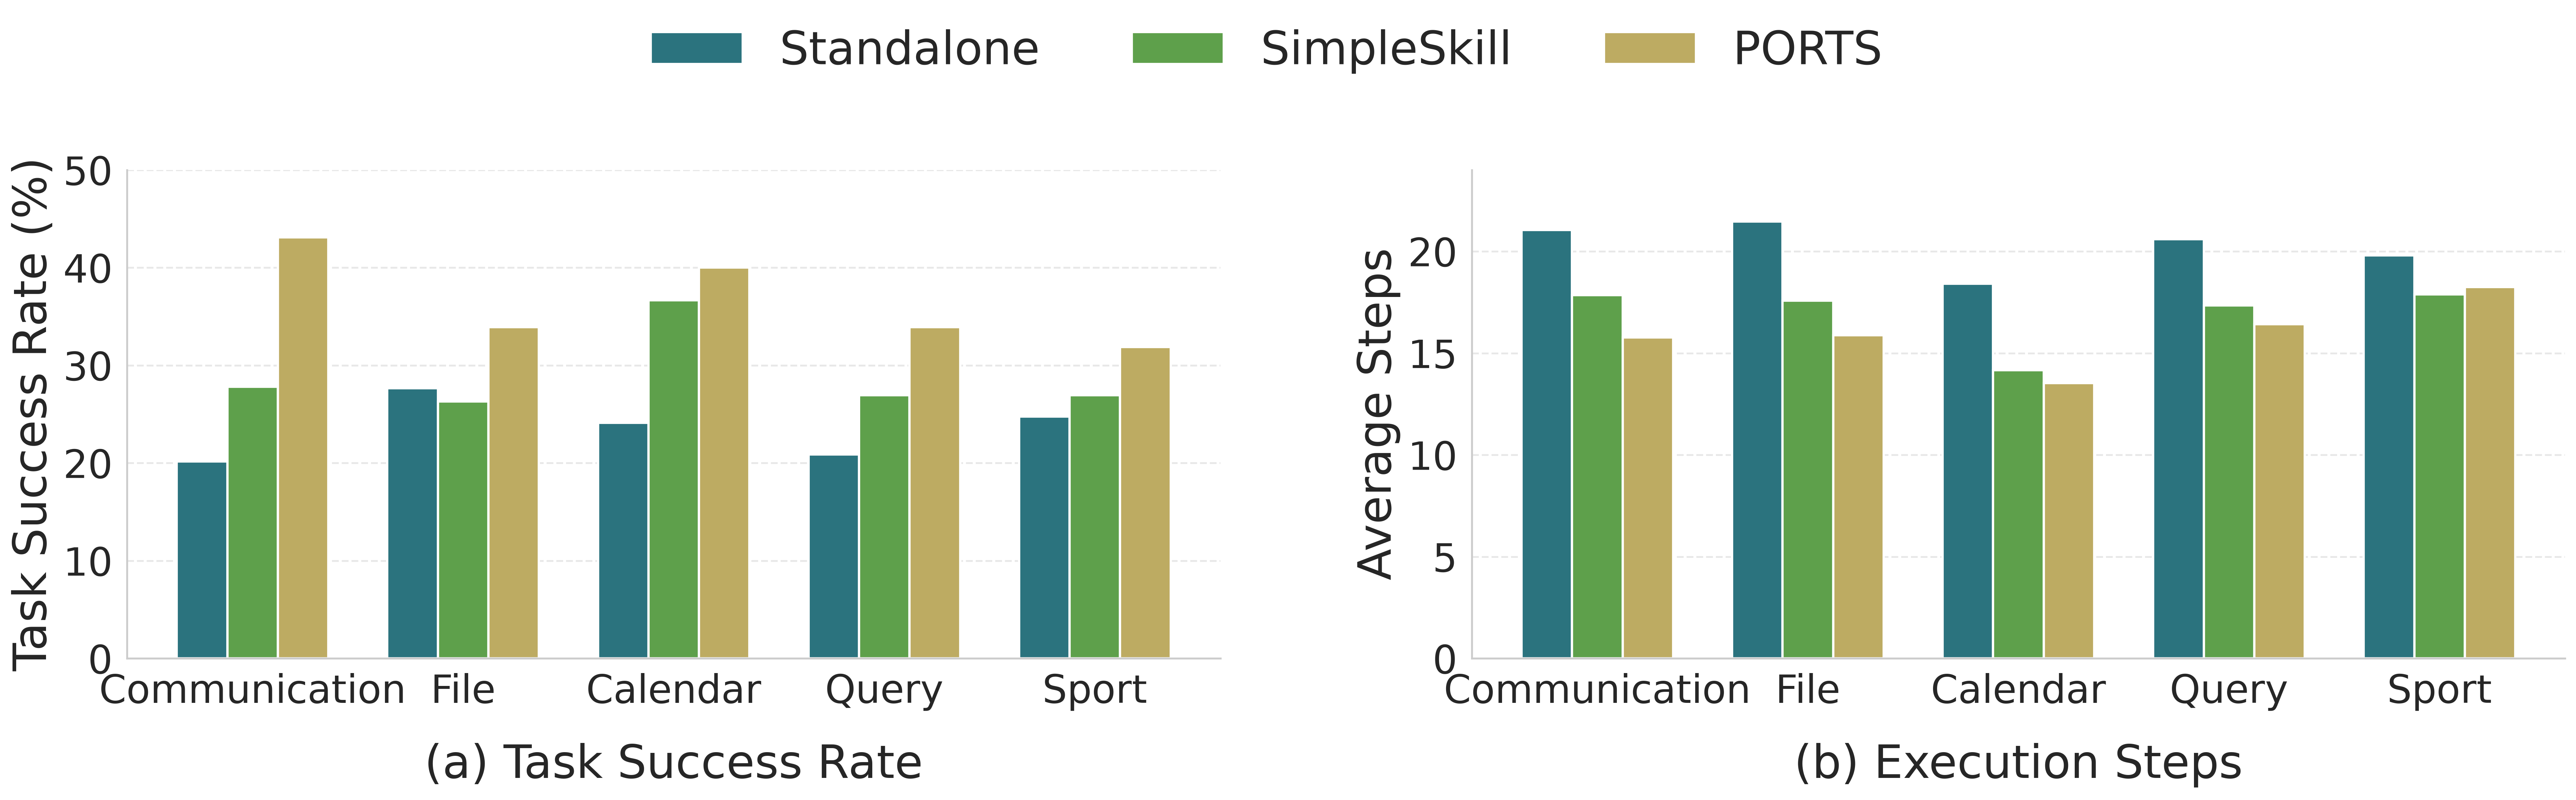

In [40]:
import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype']=42
matplotlib.rcParams['ps.fonttype']=42
import matplotlib.pyplot as plt
import seaborn as sns

models=['Communication','File','Calendar','Query','Sport']
methods=['Standalone','SimpleSkill','PORTS']

tsr=np.array([
    [0.2017544,0.2782609,0.4310345],
    [0.2767857,0.2631579,0.3391304],
    [0.2413793,0.3666667,0.4000000],
    [0.2086957,0.2695652,0.3391304],
    [0.2477876,0.2695652,0.3189655]
])*100

steps=np.array([
    [21.05263,17.84348,15.76724],
    [21.46429,17.58772,15.88696],
    [18.41379,14.16667,13.53333],
    [20.60870,17.33913,16.41739],
    [19.79646,17.89565,18.25000]
])

fontsize=30
plt.rcParams['figure.dpi']=300
plt.rcParams['font.family']='sans-serif'
sns.set_theme(style='whitegrid',rc={'font.size':fontsize,'axes.labelsize':fontsize,'axes.titlesize':fontsize,'font.weight':'normal'})

palette=sns.color_palette('gist_earth',3)
x=np.arange(len(models))
width=0.24

fig,axs=plt.subplots(1,2,figsize=(24,7.5))

for i,method in enumerate(methods):
    axs[0].bar(x+(i-1)*width,tsr[:,i],width=width,label=method,color=palette[i],edgecolor='white',linewidth=1.5)
    axs[1].bar(x+(i-1)*width,steps[:,i],width=width,label=method,color=palette[i],edgecolor='white',linewidth=1.5)

axs[0].set_ylabel('Task Success Rate (%)',fontsize=fontsize)
axs[1].set_ylabel('Average Steps',fontsize=fontsize)

axs[0].set_xticks(x)
axs[1].set_xticks(x)
axs[0].set_xticklabels(models,fontsize=fontsize*0.85)
axs[1].set_xticklabels(models,fontsize=fontsize*0.85)

axs[0].set_ylim(0,50)
axs[1].set_ylim(0,24)

axs[0].set_yticks(np.arange(0,51,10))
axs[1].set_yticks(np.arange(0,25,5))

axs[0].tick_params(axis='y',labelsize=fontsize*0.85)
axs[1].tick_params(axis='y',labelsize=fontsize*0.85)

axs[0].grid(axis='x',visible=False)
axs[1].grid(axis='x',visible=False)
axs[0].grid(axis='y',linestyle='--',linewidth=1.2,alpha=0.45)
axs[1].grid(axis='y',linestyle='--',linewidth=1.2,alpha=0.45)

axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

axs[0].text(0.5,-0.22,'(a) Task Success Rate',transform=axs[0].transAxes,fontsize=fontsize,ha='center',va='center')
axs[1].text(0.5,-0.22,'(b) Execution Steps',transform=axs[1].transAxes,fontsize=fontsize,ha='center',va='center')

handles,labels=axs[0].get_legend_handles_labels()
fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(0.5,1.04),ncol=3,frameon=False,fontsize=fontsize)

plt.subplots_adjust(left=0.07,right=0.99,top=0.82,bottom=0.23,wspace=0.23)

plt.savefig('/home/zmz/Workspace/gui/figures/outputs/tsr_steps_comparison.pdf',format='pdf',bbox_inches='tight',pad_inches=0.05)
plt.savefig('/home/zmz/Workspace/gui/figures/outputs/tsr_steps_comparison.png',dpi=300,bbox_inches='tight',pad_inches=0.05)
plt.show()